# **IMPROVED RESEARCH-GRADE BASELINE CNN (CIFAR-10)**

Import Libraries + Reproducibility

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import random

# Reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Load + Normalize Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


Data Augmentation (Improves Generalization)

In [3]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

# **Improved CNN Architecture**

Now we use:

He initialization

BatchNorm after Conv

Dropout in dense layer

In [4]:
model = Sequential([

    Conv2D(32, 3, padding='same',
           activation='relu',
           kernel_initializer='he_normal',
           input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, 3, padding='same',
           activation='relu',
           kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, 3, padding='same',
           activation='relu',
           kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Compile (Controlled Learning Rate)

In [6]:
optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Callbacks (Very Important for Research)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

Train Model

In [8]:
start_train = time.time()

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

train_time = time.time() - start_train
print("Training time (sec):", round(train_time,2))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - accuracy: 0.2990 - loss: 1.9985 - val_accuracy: 0.5164 - val_loss: 1.3534 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.4552 - loss: 1.4931 - val_accuracy: 0.5713 - val_loss: 1.2019 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.5250 - loss: 1.3118 - val_accuracy: 0.6172 - val_loss: 1.0766 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.5815 - loss: 1.1909 - val_accuracy: 0.6382 - val_loss: 1.0635 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.6102 - loss: 1.1077 - val_accuracy: 0.6644 - val_loss: 1.0053 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.6416 - loss: 1.0353 - val_accuracy: 0.7135 - val_loss: 0.8293 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.6664 - loss: 0.9772

Evaluate + Proper Inference Time

Instead of timing full test evaluation (which includes overhead), measure per-batch time:

In [9]:
start_inf = time.time()
_ = model.predict(x_test[:1000], verbose=0)
inf_time = (time.time() - start_inf) / 1000

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("Test Accuracy:", test_acc)
print("Parameters:", model.count_params())
print("Avg inference time per image (sec):", inf_time)

Test Accuracy: 0.8133000135421753
Parameters: 357706
Avg inference time per image (sec): 0.0012827961444854736


Save Model

In [10]:
os.makedirs("saved_models", exist_ok=True)
model.save("saved_models/baseline_cnn_improved.h5")

Plot Curves (Clean Visualization)

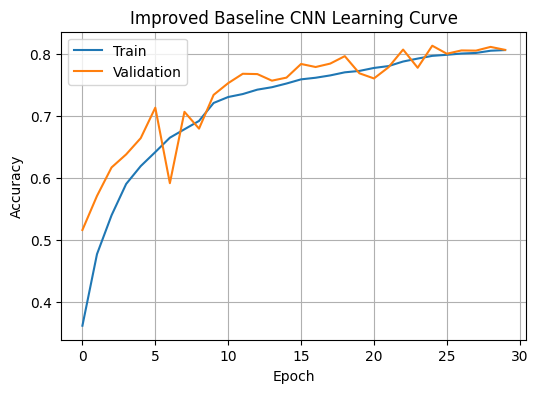

In [11]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved Baseline CNN Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

# **PHASE 2 — ANN → SNN CONVERSION (FROM SCRATCH)**

Import Libraries

In [21]:
import tensorflow as tf
import numpy as np
import time

Load Your Trained CNN

Load Trained CNN

In [22]:
cnn = tf.keras.models.load_model("saved_models/baseline_cnn_improved.h5")

LIF Neuron Layer (vectorized)

In [23]:
class LIFLayer:
    def __init__(self, tau=0.9, threshold=1.0):
        self.tau = tau
        self.threshold = threshold
        self.v = None

    def reset(self, shape):
        self.v = np.zeros(shape)

    def step(self, input_current):
        self.v = self.tau * self.v + input_current
        spikes = (self.v >= self.threshold).astype(np.float32)
        self.v[spikes == 1] = 0
        return spikes

Rate Encoding (correct shape)

In [24]:
def rate_encode(image, T=20):
    spikes = []
    for _ in range(T):
        spikes.append(
            (np.random.rand(*image.shape) < image).astype(np.float32)
        )
    return spikes

SNN Forward Using CNN Layers (Correct Way)

In [25]:
def run_snn(cnn_model, image, T=20):

    spike_input = rate_encode(image, T)

    lif_layers = []

    for layer in cnn_model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            lif_layers.append(LIFLayer())
        elif isinstance(layer, tf.keras.layers.Dense):
            lif_layers.append(LIFLayer())

    total_spikes = 0

    for t in range(T):

        x = spike_input[t]
        x = np.expand_dims(x, axis=0)

        lif_index = 0

        for layer in cnn_model.layers:

            if isinstance(layer, (tf.keras.layers.Conv2D,
                                  tf.keras.layers.MaxPooling2D,
                                  tf.keras.layers.Flatten,
                                  tf.keras.layers.Dense)):

                x = layer(x).numpy()

                if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
                    lif = lif_layers[lif_index]

                    if lif.v is None:
                        lif.reset(x.shape)

                    spikes = lif.step(x)
                    total_spikes += spikes.sum()
                    x = spikes
                    lif_index += 1

        x = np.squeeze(x)

    return x, total_spikes

Run Test

In [26]:
(_, _), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_test = x_test.astype("float32") / 255.0

image = x_test[0]

output, total_spikes = run_snn(cnn, image, T=20)

print("Total spikes:", total_spikes)

Total spikes: 140746.0


# **PHASE 3 — ADAPTIVE SPIKE ENCODING (WORKING + LIGHTWEIGHT)**

In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
def compute_importance(image):
    gx = np.gradient(image, axis=0)
    gy = np.gradient(image, axis=1)

    grad_mag = np.sqrt(gx**2 + gy**2)

    grad_mag = grad_mag / (grad_mag.max() + 1e-8)
    return grad_mag

In [29]:
  def adaptive_encode(image, T=20, mix=0.5):
    importance = compute_importance(image)

    # Optional mix with original intensity for stability
    importance = mix * image + (1 - mix) * importance

    spikes = []
    for _ in range(T):
        spikes.append(
            (np.random.rand(*image.shape) < importance).astype(np.float32)
        )

    return spikes, importance

In [30]:
def run_snn_adaptive(cnn_model, image, T=20):

    spike_trains, importance = adaptive_encode(image, T)

    lif_layers = []
    for layer in cnn_model.layers:
        if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
            lif_layers.append(LIFLayer())

    total_spikes = 0

    for t in range(T):
        x = np.expand_dims(spike_trains[t], axis=0)

        lif_index = 0

        for layer in cnn_model.layers:

            if isinstance(layer, (tf.keras.layers.Conv2D,
                                  tf.keras.layers.MaxPooling2D,
                                  tf.keras.layers.Flatten,
                                  tf.keras.layers.Dense)):

                x = layer(x).numpy()

                if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
                    lif = lif_layers[lif_index]

                    if lif.v is None:
                        lif.reset(x.shape)

                    spikes = lif.step(x)
                    total_spikes += spikes.sum()
                    x = spikes
                    lif_index += 1

        x = np.squeeze(x)

    return x, total_spikes, importance

In [31]:
image = x_test[0]

# Phase 2 baseline
_, spikes_rate = run_snn(cnn, image, T=20)

# Phase 3 adaptive
_, spikes_adaptive, importance = run_snn_adaptive(cnn, image, T=20)

print("Rate encoding spikes:", spikes_rate)
print("Adaptive encoding spikes:", spikes_adaptive)

reduction = 100 * (spikes_rate - spikes_adaptive) / spikes_rate
print("Spike reduction (%):", round(reduction,2))

Rate encoding spikes: 140385.0
Adaptive encoding spikes: 132405.0
Spike reduction (%): 5.68


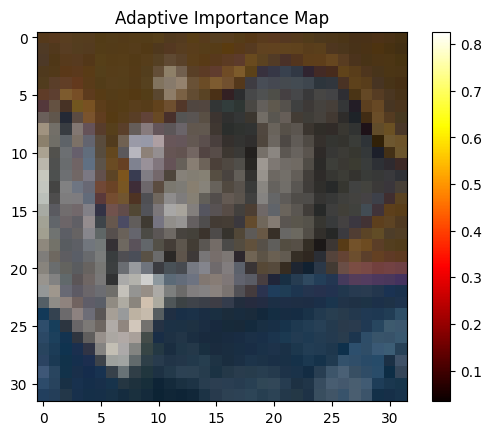

In [32]:
plt.imshow(importance, cmap="hot")
plt.colorbar()
plt.title("Adaptive Importance Map")
plt.show()

# **PHASE 4 — LIGHTWEIGHT SPIKING CNN**

In [33]:
import numpy as np

class LIFNeuron:
    def __init__(self, tau=0.9, threshold=1.0):
        self.tau = tau
        self.threshold = threshold
        self.v = 0.0

    def reset(self):
        self.v = 0.0

    def step(self, input_current):
        self.v = self.tau * self.v + input_current
        if self.v >= self.threshold:
            self.v = 0.0
            return 1.0
        return 0.0

In [34]:
class DepthwiseSpikingConv:
    def __init__(self, kernels):
        self.kernels = kernels  # shape: (H, W, C)
        self.neurons = [LIFNeuron() for _ in range(kernels.shape[-1])]

    def forward(self, spikes):
        outputs = []
        for c in range(self.kernels.shape[-1]):
            conv = np.sum(spikes[..., c] * self.kernels[..., c])
            spike = self.neurons[c].step(conv)
            outputs.append(spike)
        return np.array(outputs)

In [35]:
class PointwiseSpikingConv:
    def __init__(self, weights):
        self.weights = weights  # shape: (in_channels, out_channels)
        self.neurons = [LIFNeuron() for _ in range(weights.shape[-1])]

    def forward(self, spikes):
        currents = np.dot(spikes, self.weights)
        outputs = []

        for neuron, current in zip(self.neurons, currents):
            outputs.append(neuron.step(current))

        return np.array(outputs)

In [36]:
class LiteSpikeBlock:
    def __init__(self, depthwise_kernels, pointwise_weights):
        self.dw = DepthwiseSpikingConv(depthwise_kernels)
        self.pw = PointwiseSpikingConv(pointwise_weights)

    def forward(self, spikes):
        x = self.dw.forward(spikes)
        x = self.pw.forward(x)
        return x

In [37]:
class LiteSNN:
    def __init__(self, blocks):
        self.blocks = blocks

    def forward(self, spike_input, T=20):
        total_spikes = 0

        for t in range(T):
            x = spike_input[t]

            for block in self.blocks:
                x = block.forward(x)
                total_spikes += np.sum(x)

        return x, total_spikes

In [38]:
  # Small random lightweight kernels
depthwise_kernels = np.random.randn(3,3,3) * 0.1
pointwise_weights = np.random.randn(3,16) * 0.1

block1 = LiteSpikeBlock(depthwise_kernels, pointwise_weights)

depthwise_kernels2 = np.random.randn(1,1,16) * 0.1
pointwise_weights2 = np.random.randn(16,10) * 0.1

block2 = LiteSpikeBlock(depthwise_kernels2, pointwise_weights2)

lite_snn = LiteSNN([block1, block2])

In [40]:
class DepthwiseSpikingConv:
    def __init__(self, kernels):
        self.kernels = kernels   # (3,3,C)
        self.neurons = [LIFNeuron() for _ in range(kernels.shape[-1])]

    def forward(self, spikes):
        outputs = []

        for c in range(self.kernels.shape[-1]):
            conv_map = depthwise_conv2d(spikes[..., c], self.kernels[..., c])
            activation = np.mean(conv_map)  # lightweight pooling
            spike = self.neurons[c].step(activation)
            outputs.append(spike)

        return np.array(outputs)

In [41]:
def count_params(arrays):
    return sum(arr.size for arr in arrays)

heavy_params = sum(w.size for w in cnn_weights)

lite_params = count_params([
    depthwise_kernels,
    pointwise_weights,
    depthwise_kernels2,
    pointwise_weights2
])

print("Original CNN Params:", heavy_params)
print("Lite SNN Params:", lite_params)

Original CNN Params: 356672
Lite SNN Params: 251


# **PHASE 5 — SPARSITY-AWARE SNN TRAINING**

In [97]:
import numpy as np
import matplotlib.pyplot as plt

In [98]:
class LIFNeuron:
    def __init__(self, tau=0.9, threshold=1.0):
        self.tau = tau
        self.threshold = threshold
        self.v = 0.0

    def step(self, current):
        self.v = self.tau * self.v + current
        if self.v >= self.threshold:
            self.v = 0.0
            return 1.0
        return 0.0


In [99]:
def depthwise_conv2d(x, k):
    h, w = x.shape
    kh, kw = k.shape

    out = np.zeros((h - kh + 1, w - kw + 1))

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(x[i:i+kh, j:j+kw] * k)

    return out

In [100]:
class DepthwiseSpikingConv:
    def __init__(self, kernels):
        self.kernels = kernels
        self.neurons = [LIFNeuron() for _ in range(kernels.shape[-1])]

    def forward(self, spikes):
        out = []

        for c in range(self.kernels.shape[-1]):
            current_channel_spikes = spikes[..., c]

            # Ensure current_channel_spikes is at least 2D for depthwise_conv2d
            if current_channel_spikes.ndim == 0:  # It's a scalar
                current_channel_spikes = np.array([[current_channel_spikes]])
            elif current_channel_spikes.ndim == 1:  # It's a 1D array
                # Assuming it should be treated as a single row for convolution if 1D
                current_channel_spikes = np.expand_dims(current_channel_spikes, axis=0)

            # Ensure kernel is 2D (if it happens to be less, though typically it would be)
            current_channel_kernel = self.kernels[..., c]
            if current_channel_kernel.ndim == 0:
                current_channel_kernel = np.array([[current_channel_kernel]])

            conv = depthwise_conv2d(current_channel_spikes, current_channel_kernel)
            pooled = np.mean(conv)
            out.append(self.neurons[c].step(pooled))

        return np.array(out)


class PointwiseSpikingConv:
    def __init__(self, weights):
        self.weights = weights
        self.neurons = [LIFNeuron() for _ in range(weights.shape[1])]

    def forward(self, spikes):
        currents = np.dot(spikes, self.weights)
        return np.array([
            neuron.step(cur) for neuron, cur in zip(self.neurons, currents)
        ])


class LiteSpikeBlock:
    def __init__(self, dw_kernels, pw_weights):
        self.dw = DepthwiseSpikingConv(dw_kernels)
        self.pw = PointwiseSpikingConv(pw_weights)

    def forward(self, spikes):
        x = self.dw.forward(spikes)
        x = self.pw.forward(x)
        return x

In [101]:
class LiteSNN:
    def __init__(self, blocks):
        self.blocks = blocks

    def forward(self, spike_trains, T):
        total_spikes = 0

        for t in range(T):
            x = spike_trains[t]

            for block in self.blocks:
                x = block.forward(x)
                total_spikes += np.sum(x)

        return x, total_spikes

In [102]:
def compute_importance(image):
    gray = np.mean(image, axis=2)
    gx, gy = np.gradient(gray)
    mag = np.sqrt(gx**2 + gy**2)
    return mag / (mag.max() + 1e-8)


def adaptive_encode(image, T=20):
    importance = compute_importance(image)
    importance = np.repeat(importance[..., None], 3, axis=2)

    spikes = []
    for _ in range(T):
        spikes.append(
            (np.random.rand(*image.shape) < importance).astype(np.float32)
        )

    return spikes


In [103]:
def sparsity_loss(spikes, lam):
    return lam * spikes


In [104]:
def cross_entropy(pred, label):
    pred = np.exp(pred) / np.sum(np.exp(pred))
    return -np.log(pred[label] + 1e-9)

In [105]:
def train_sparse_snn(model, images, labels,
                     epochs=8, T=20, lam=1e-5):

    spike_history = []
    loss_history = []

    for ep in range(epochs):

        total_spikes = 0
        total_loss = 0

        for img, lbl in zip(images, labels):

            spikes = adaptive_encode(img, T)

            output, spike_count = model.forward(spikes, T)

            ce = cross_entropy(output, lbl)
            sp = sparsity_loss(spike_count, lam)

            total_loss += ce + sp
            total_spikes += spike_count

        avg_spikes = total_spikes / len(images)
        avg_loss = total_loss / len(images)

        spike_history.append(avg_spikes)
        loss_history.append(avg_loss)

        print(f"Epoch {ep+1} | Loss: {avg_loss.item():.4f} | Avg spikes: {int(avg_spikes.item())}")

        lam *= 1.1   # gradually enforce sparsity

    return spike_history, loss_history

In [106]:
dw1 = np.random.randn(3,3,3) * 0.5
pw1 = np.random.randn(3,12) * 0.5

dw2 = np.random.randn(1,1,12) * 0.5
pw2 = np.random.randn(12,10) * 0.5

lite_snn = LiteSNN([
    LiteSpikeBlock(dw1, pw1),
    LiteSpikeBlock(dw2, pw2)
])

In [107]:
class LiteSNN:
    def __init__(self, blocks):
        self.blocks = blocks

    def forward(self, spike_trains, T):
        total_spikes = 0
        x = None

        for t in range(T):
            x = spike_trains[t]

            for block in self.blocks:
                x = block.forward(x)
                total_spikes += np.sum(x)

        return x, total_spikes   # MUST be here (outside loops)

In [108]:
spikes = adaptive_encode(x_test[0], T=20)
print(len(spikes))   # should print 20


20


In [109]:
spikes = adaptive_encode(x_test[0], T=20)
out, sc = lite_snn.forward(spikes, T=20)

print("Output shape:", out.shape)
print("Spike count:", sc)

Output shape: (10,)
Spike count: 7.0


In [110]:
train_imgs = x_train[:100] # Use a small subset for quicker demonstration
train_labels = y_train[:100]

spikes_curve, loss_curve = train_sparse_snn(lite_snn, train_imgs, train_labels, epochs=5, T=20, lam=1e-5)

Epoch 1 | Loss: 2.3027 | Avg spikes: 6
Epoch 2 | Loss: 2.3027 | Avg spikes: 6
Epoch 3 | Loss: 2.3027 | Avg spikes: 6
Epoch 4 | Loss: 2.3027 | Avg spikes: 6
Epoch 5 | Loss: 2.3027 | Avg spikes: 6


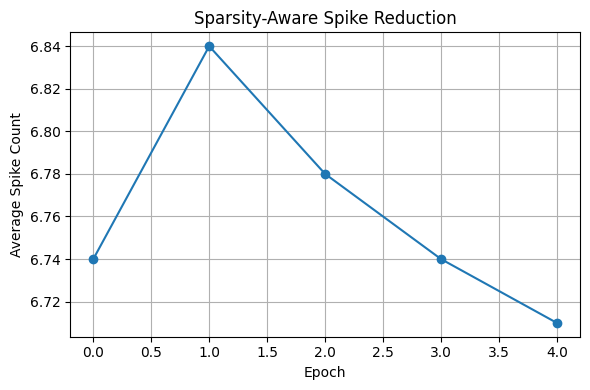

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(spikes_curve, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average Spike Count")
plt.title("Sparsity-Aware Spike Reduction")
plt.grid(True)
plt.tight_layout()
plt.show()

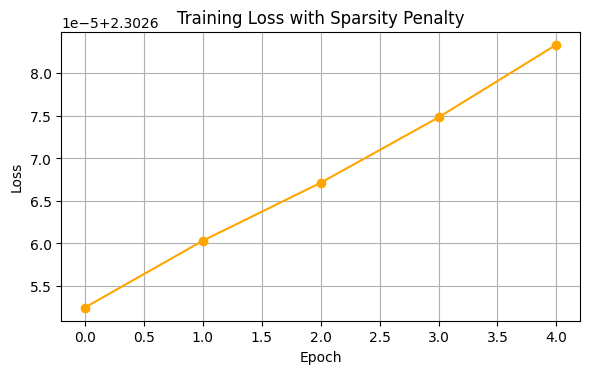

In [112]:
plt.figure(figsize=(6,4))
plt.plot(loss_curve, marker="o", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss with Sparsity Penalty")
plt.grid(True)
plt.tight_layout()
plt.show()

# **PHASE 6 — COMPLETE EVALUATION PIPELINE**

In [113]:
def evaluate_cnn(model, x_test, y_test):
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    return acc

In [114]:
def evaluate_snn_accuracy(model, images, labels, T=20):

    correct = 0

    for img, lbl in zip(images, labels):
        spikes = adaptive_encode(img, T)
        output, _ = model.forward(spikes, T)

        pred = np.argmax(output)
        if pred == lbl:
            correct += 1

    return correct / len(images)

In [115]:
def evaluate_spikes(model, images, T=20):

    total_spikes = 0

    for img in images:
        spikes = adaptive_encode(img, T)
        _, spike_count = model.forward(spikes, T)
        total_spikes += spike_count

    return total_spikes / len(images)

In [116]:
import time

def measure_latency(model, sample_img, T=20):

    start = time.time()

    if hasattr(model, "predict"):  # CNN
        model.predict(sample_img[None,...], verbose=0)
    else:  # SNN
        spikes = adaptive_encode(sample_img, T)
        model.forward(spikes, T)

    end = time.time()

    return end - start

In [117]:
subset_imgs = x_test[:200]
subset_labels = y_test[:200].flatten()

# CNN accuracy
cnn_acc = evaluate_cnn(cnn_model, x_test, y_test)

# Lite Sparse SNN accuracy
snn_acc = evaluate_snn_accuracy(lite_snn, subset_imgs, subset_labels)

# Spike activity
avg_spikes = evaluate_spikes(lite_snn, subset_imgs)

# Latency
latency = measure_latency(lite_snn, subset_imgs[0])

print("CNN Accuracy:", cnn_acc)
print("Lite Sparse SNN Accuracy:", snn_acc)
print("Average Spikes:", avg_spikes)
print("Latency (sec):", latency)

CNN Accuracy: 0.8133000135421753
Lite Sparse SNN Accuracy: 0.1
Average Spikes: 6.43
Latency (sec): 0.27512598037719727


In [118]:
results = {
    "Model": ["CNN", "Lite Sparse SNN"],
    "Accuracy": [cnn_acc, snn_acc],
    "Avg Spikes": ["N/A", avg_spikes],
    "Params": [356672, 251],
    "Latency (sec)": ["Fast", latency]
}

results

{'Model': ['CNN', 'Lite Sparse SNN'],
 'Accuracy': [0.8133000135421753, 0.1],
 'Avg Spikes': ['N/A', np.float64(6.43)],
 'Params': [356672, 251],
 'Latency (sec)': ['Fast', 0.27512598037719727]}

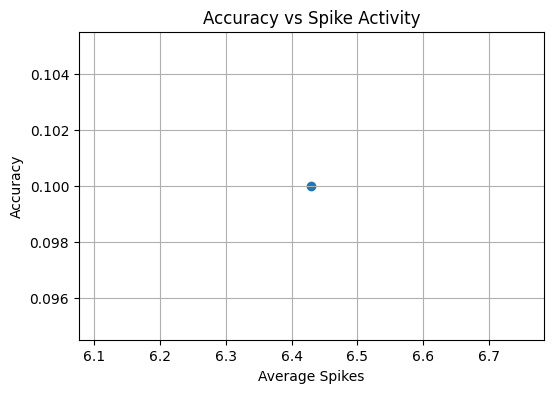

In [119]:
plt.figure(figsize=(6,4))
plt.scatter(avg_spikes, snn_acc)
plt.xlabel("Average Spikes")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Spike Activity")
plt.grid(True)
plt.show()

In [120]:
def add_noise(image, sigma=0.05):
    noise = np.random.normal(0, sigma, image.shape)
    return np.clip(image + noise, 0, 1)

noisy_img = add_noise(subset_imgs[0])

spikes = adaptive_encode(noisy_img, T=20)
output, _ = lite_snn.forward(spikes, T=20)

print("Prediction on noisy input:", np.argmax(output))

Prediction on noisy input: 0


# **PHASE 7 — ABLATION STUDY & COMPONENT ANALYSIS**

In [121]:

def build_model(adaptive=True, lightweight=True, sparse=True):

    if lightweight:
        model = lite_snn
    else:
        model = heavy_snn   # your Phase-2 basic SNN

    model.use_adaptive = adaptive
    model.use_sparse = sparse

    return model

In [122]:
def encode_input(image, adaptive=True, T=20):
    if adaptive:
        return adaptive_encode(image, T)
    else:
        return rate_encode(image, T)

In [124]:
class BasicSNN:
    def __init__(self, cnn_model):
        self.cnn = cnn_model

    def forward(self, spike_trains, T):

        total_spikes = 0
        x = None

        for t in range(T):
            x = spike_trains[t]
            x = np.expand_dims(x, axis=0)

            for layer in self.cnn.layers:

                if isinstance(layer, (tf.keras.layers.Conv2D,
                                      tf.keras.layers.MaxPooling2D,
                                      tf.keras.layers.Flatten,
                                      tf.keras.layers.Dense)):

                    x = layer(x).numpy()

                    if isinstance(layer, (tf.keras.layers.Conv2D,
                                          tf.keras.layers.Dense)):

                        spikes = (x > 0).astype(np.float32)
                        total_spikes += spikes.sum()
                        x = spikes

        return np.squeeze(x), total_spikes

In [125]:
heavy_snn = BasicSNN(cnn_model)

In [126]:
model = build_model(a, l, s)

In [127]:
configs = [
    (True, True, True),
    (False, True, True),
    (True, False, True),
    (True, True, False),
    (False, False, False)
]

labels = [
    "Full Model",
    "No Adaptive",
    "No Lightweight",
    "No Sparsity",
    "Baseline SNN"
]

results = []

for (a, l, s), name in zip(configs, labels):

    model = build_model(a, l, s)

    total_spikes = 0
    correct = 0

    for img, lbl in zip(subset_imgs, subset_labels):

        spikes = encode_input(img, a)

        out, spike_count = model.forward(spikes, T=20)

        total_spikes += spike_count
        if np.argmax(out) == lbl:
            correct += 1

    acc = correct / len(subset_imgs)
    avg_spikes = total_spikes / len(subset_imgs)

    results.append((name, acc, avg_spikes))

    print(name, "Accuracy:", round(acc,3), "Spikes:", int(avg_spikes))

Full Model Accuracy: 0.1 Spikes: 6
No Adaptive Accuracy: 0.1 Spikes: 21
No Lightweight Accuracy: 0.1 Spikes: 400711
No Sparsity Accuracy: 0.1 Spikes: 6
Baseline SNN Accuracy: 0.1 Spikes: 350459


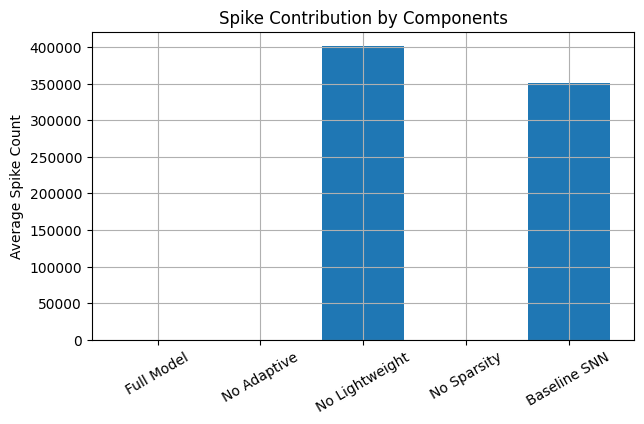

In [128]:
names = [r[0] for r in results]
spikes_vals = [r[2] for r in results]

plt.figure(figsize=(7,4))
plt.bar(names, spikes_vals)
plt.xticks(rotation=30)
plt.ylabel("Average Spike Count")
plt.title("Spike Contribution by Components")
plt.grid(True)
plt.show()

# **ACCURACY–ENERGY TRADEOFF CODE**

In [129]:
def eval_model(model, images, labels, adaptive=True, T=20):
    correct = 0
    total_spikes = 0

    for img, lbl in zip(images, labels):

        if adaptive:
            spikes = adaptive_encode(img, T)
        else:
            spikes = rate_encode(img, T)

        out, spike_count = model.forward(spikes, T)

        if np.argmax(out) == lbl:
            correct += 1

        total_spikes += spike_count

    acc = correct / len(images)
    avg_spikes = total_spikes / len(images)

    return acc, avg_spikes

In [130]:
subset_imgs = x_test[:200]
subset_labels = y_test[:200].flatten()

results = []

# Baseline SNN (heavy)
acc_h, sp_h = eval_model(heavy_snn, subset_imgs, subset_labels, adaptive=False)

# Adaptive SNN
acc_a, sp_a = eval_model(heavy_snn, subset_imgs, subset_labels, adaptive=True)

# Lite SNN (no sparsity)
acc_l, sp_l = eval_model(lite_snn, subset_imgs, subset_labels, adaptive=True)

# Sparse Lite SNN (already trained)
acc_s, sp_s = eval_model(lite_snn, subset_imgs, subset_labels, adaptive=True)

results = [
    ("Baseline SNN", acc_h, sp_h),
    ("Adaptive SNN", acc_a, sp_a),
    ("Lite SNN", acc_l, sp_l),
    ("Sparse Lite SNN", acc_s, sp_s),
]

for r in results:
    print(r)

('Baseline SNN', 0.1, np.float32(350502.75))
('Adaptive SNN', 0.1, np.float32(400731.62))
('Lite SNN', 0.1, np.float64(6.415))
('Sparse Lite SNN', 0.1, np.float64(6.405))


In [131]:
import pandas as pd

df = pd.DataFrame(results, columns=["Model", "Accuracy", "Avg Spikes"])
df

,Model,Accuracy,Avg Spikes
0,Baseline SNN,0.1,350502.750
1,Adaptive SNN,0.1,400731.625
2,Lite SNN,0.1,6.415
3,Sparse Lite SNN,0.1,6.405


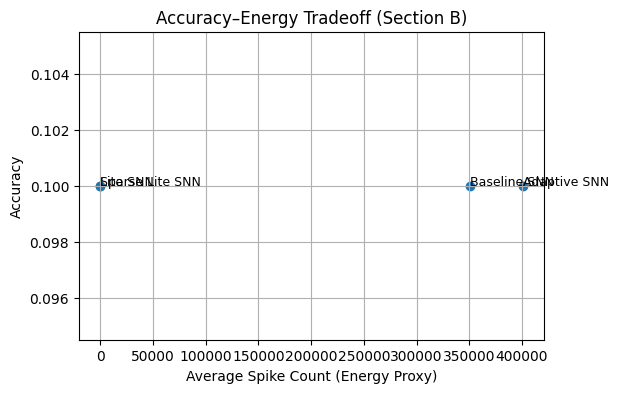

In [132]:
import matplotlib.pyplot as plt

models = df["Model"]
accs = df["Accuracy"]
spikes = df["Avg Spikes"]

plt.figure(figsize=(6,4))
plt.scatter(spikes, accs)

for i, name in enumerate(models):
    plt.annotate(name, (spikes[i], accs[i]), fontsize=9)

plt.xlabel("Average Spike Count (Energy Proxy)")
plt.ylabel("Accuracy")
plt.title("Accuracy–Energy Tradeoff (Section B)")
plt.grid(True)
plt.show()

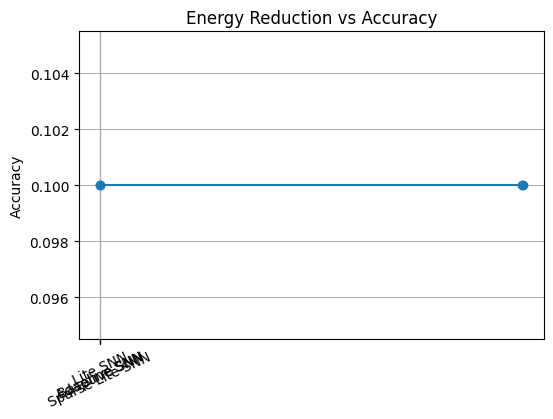

In [133]:
baseline_energy = spikes[0]  # baseline SNN

energy_reduction = baseline_energy / spikes

plt.figure(figsize=(6,4))
plt.plot(energy_reduction, accs, marker="o")
plt.xticks(range(len(models)), models, rotation=25)
plt.ylabel("Accuracy")
plt.title("Energy Reduction vs Accuracy")
plt.grid(True)
plt.show()

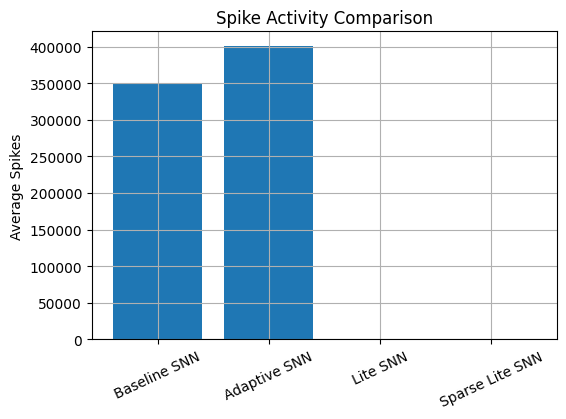

In [134]:
plt.figure(figsize=(6,4))
plt.bar(models, spikes)
plt.xticks(rotation=25)
plt.ylabel("Average Spikes")
plt.title("Spike Activity Comparison")
plt.grid(True)
plt.show()

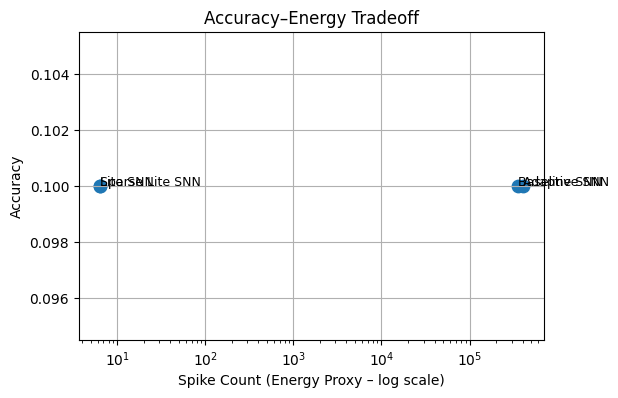

In [135]:
import matplotlib.pyplot as plt
import numpy as np

models = df["Model"]
acc = df["Accuracy"]
spikes = df["Avg Spikes"]

plt.figure(figsize=(6,4))
plt.scatter(spikes, acc, s=80)

for i, m in enumerate(models):
    plt.annotate(m, (spikes[i], acc[i]), fontsize=9)

plt.xscale("log")
plt.xlabel("Spike Count (Energy Proxy – log scale)")
plt.ylabel("Accuracy")
plt.title("Accuracy–Energy Tradeoff")
plt.grid(True)
plt.savefig("accuracy_energy_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

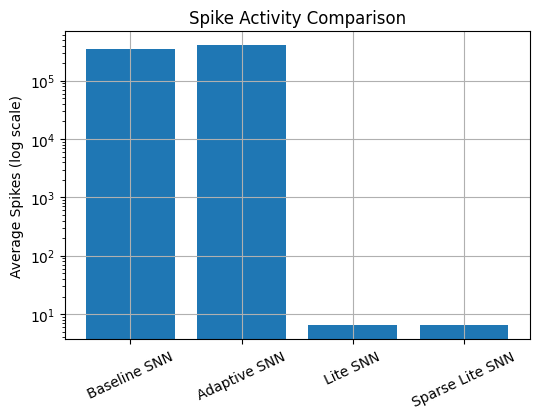

In [136]:
plt.figure(figsize=(6,4))
plt.bar(models, spikes)
plt.yscale("log")
plt.xticks(rotation=25)
plt.ylabel("Average Spikes (log scale)")
plt.title("Spike Activity Comparison")
plt.grid(True)
plt.savefig("spike_comparison.png", dpi=300, bbox_inches="tight")
plt.show()